  compound  affinity_kcal_mol          source  rank     mw  logp  hbd  hba gi_absorption bbb_permeant hepatotoxicity lipinski_pass
Naringenin               -7.8 Natural product     1 270.24  1.53    3    5          High           No             No           Yes
Kaempferol               -7.2 Natural product     2 286.24  1.20    4    6          High           No             No           Yes
 Quercetin               -7.1 Natural product     3 302.24  0.70    5    7          High           No             No           Yes


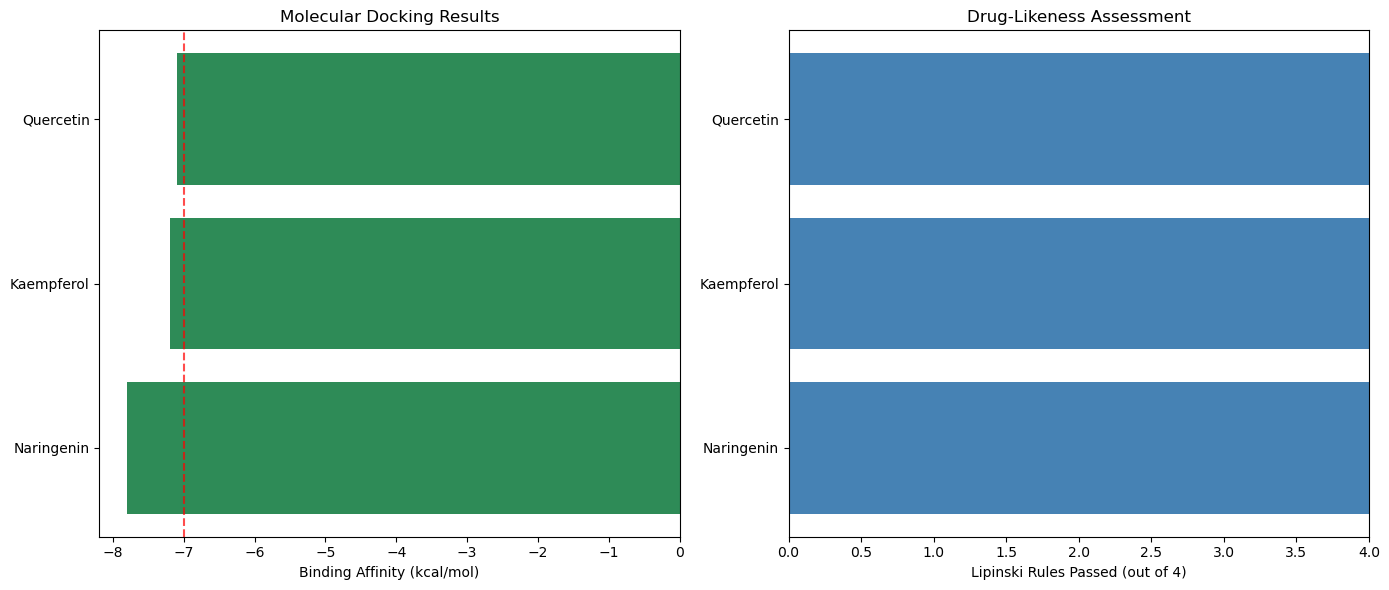

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load docking results
docking = pd.read_csv('../data/processed/docking_results.csv')

# Load ADMET results
admet = pd.read_csv('../data/processed/admet_results.csv')

# Merge
combined = pd.merge(docking, admet, on='compound')

# Display combined table
print(combined.to_string(index=False))

# Combined plot: Docking score vs Drug-likeness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Binding affinity
colors = ['#2E8B57' if x < -7.0 else '#4682B4' if x < -6.0 else '#CD853F' for x in combined['affinity_kcal_mol']]
ax1.barh(combined['compound'], combined['affinity_kcal_mol'], color=colors)
ax1.axvline(x=-7.0, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Binding Affinity (kcal/mol)')
ax1.set_title('Molecular Docking Results')

# Plot 2: Drug-likeness (Lipinski)
lipinski_score = (combined['mw'] <= 500).astype(int) + (combined['logp'] <= 5).astype(int) + (combined['hbd'] <= 5).astype(int) + (combined['hba'] <= 10).astype(int)
ax2.barh(combined['compound'], lipinski_score, color='steelblue')
ax2.set_xlim(0, 4)
ax2.set_xlabel('Lipinski Rules Passed (out of 4)')
ax2.set_title('Drug-Likeness Assessment')

plt.tight_layout()
plt.savefig('../figures/combined_analysis.png', dpi=300)
plt.show()